In [1]:
!pip install google-cloud-bigquery pandas-gbq

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_gbq

from google.colab import auth
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# CELL 1 — LOAD DATA DENGAN FITUR YANG SAMA SEPERTI BIGQUERY ML


import pandas as pd
import numpy as np
import pandas_gbq

project_id = "projecttcc-494604"

query = """
SELECT
  repo_name,
  subject,
  message,
  LENGTH(subject) AS subject_length,
  LENGTH(message) AS message_length,
  EXTRACT(HOUR FROM committer.date) AS commit_hour,
  EXTRACT(YEAR FROM committer.date) AS commit_year,
  ARRAY_LENGTH(difference) AS files_changed,

  (
    SELECT COUNTIF(STARTS_WITH(line, '+') AND NOT STARTS_WITH(line, '+++'))
    FROM UNNEST(difference) AS diff,
         UNNEST(SPLIT(TO_JSON_STRING(diff), '\\n')) AS line
  ) AS insertions,

  (
    SELECT COUNTIF(STARTS_WITH(line, '-') AND NOT STARTS_WITH(line, '---'))
    FROM UNNEST(difference) AS diff,
         UNNEST(SPLIT(TO_JSON_STRING(diff), '\\n')) AS line
  ) AS deletions,

  (
    (
      SELECT COUNTIF(STARTS_WITH(line, '+') AND NOT STARTS_WITH(line, '+++'))
      FROM UNNEST(difference) AS diff,
           UNNEST(SPLIT(TO_JSON_STRING(diff), '\\n')) AS line
    )
    -
    (
      SELECT COUNTIF(STARTS_WITH(line, '-') AND NOT STARTS_WITH(line, '---'))
      FROM UNNEST(difference) AS diff,
           UNNEST(SPLIT(TO_JSON_STRING(diff), '\\n')) AS line
    )
  ) AS net_change

FROM `bigquery-public-data.github_repos.sample_commits`
WHERE subject IS NOT NULL
  AND message IS NOT NULL
  AND difference IS NOT NULL
LIMIT 50000
"""

df = pandas_gbq.read_gbq(query, project_id=project_id)

print("Dataset loaded:", df.shape)
df.head()

Downloading: 100%|██████████|
Dataset loaded: (50000, 11)


,repo_name,subject,message,subject_length,message_length,commit_hour,commit_year,files_changed,insertions,deletions,net_change
0,torvalds/linux,"Revert ""staging: tidspbridge - move all iommu ...","Revert ""staging: tidspbridge - move all iommu ...",73,306,0,2010,7,0,0,0
1,torvalds/linux,block: Split bios on chunk boundaries,block: Split bios on chunk boundaries\n\nFor h...,37,446,0,2015,1,0,0,0
2,torvalds/linux,"Btrfs: ioctl, don't re-lock extent range when ...","Btrfs: ioctl, don't re-lock extent range when ...",59,843,0,2014,1,0,0,0
3,torvalds/linux,Btrfs: fix a crash of clone with inline extent...,Btrfs: fix a crash of clone with inline extent...,55,733,0,2014,2,0,0,0
4,facebook/react,Merge pull request #3560 from mariodu/mariodu,Merge pull request #3560 from mariodu/mariodu\...,45,94,0,2015,1,0,0,0


In [4]:
# CELL 2 — PREPROCESSING

model_df = df[[
    "subject_length",
    "message_length",
    "commit_hour",
    "commit_year",
    "insertions",
    "deletions",
    "net_change",
    "files_changed"
]].copy()

print("Before cleaning:", model_df.shape)
print(model_df.isna().sum())

# isi missing numerik dengan median
for col in model_df.columns:
    model_df[col] = model_df[col].fillna(model_df[col].median())

print("\nAfter fillna:", model_df.shape)
print(model_df.isna().sum())

Before cleaning: (50000, 8)
subject_length    0
message_length    0
commit_hour       0
commit_year       0
insertions        0
deletions         0
net_change        0
files_changed     0
dtype: int64

After fillna: (50000, 8)
subject_length    0
message_length    0
commit_hour       0
commit_year       0
insertions        0
deletions         0
net_change        0
files_changed     0
dtype: int64


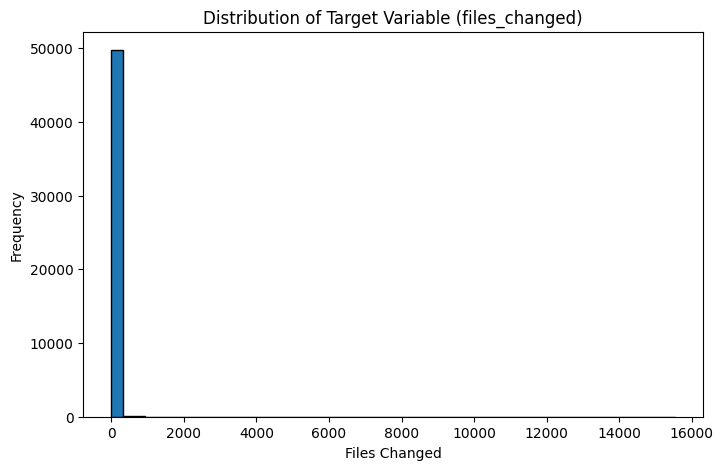

In [14]:
# VISUALISASI TARGET (files_changed)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["files_changed"], bins=50, edgecolor="black")
plt.xlabel("Files Changed")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable (files_changed)")
plt.show()

In [5]:
# CELL 3 — FEATURE / TARGET SPLIT

X = model_df.drop(columns=["files_changed"])
y = model_df["files_changed"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 7)
y shape: (50000,)


In [6]:
# CELL 4 — TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)

Train shape: (40000, 7) (40000,)
Test shape : (10000, 7) (10000,)


In [7]:
# CELL 5 — TRAIN LINEAR REGRESSION

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [8]:
# CELL 6 — PREDICTION

y_pred = lr.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [13]:
# CELL 7 — EVALUATION

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_mae = mean_absolute_error(y_test, y_pred)
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred)

In [12]:
print("Linear Regression Evaluation")
print("=" * 40)
print(f"MAE  : {lr_mae:.4f}")
print(f"MSE  : {lr_mse:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Evaluation
MAE  : 0.7256
MSE  : 70.8916
RMSE : 8.4197
R²   : 0.9994
